<a href="https://colab.research.google.com/github/Nikoldbautista/Introduccion_ciencia_de_datos-/blob/main/Informe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analisis de clientes

|variable|Tipo de Varibale|Descripcion|
|---|---|---|
|CustomerID|Entera(int)|Es el numero de Clientes
|Age|Entera(int)|Los edad del cliente  
|Education|Objeto(object)|Que nivel de educacion tiene
|Income|Entera(int)|Salario del cliente
|Occupation|Objeto(object)|Cual es la ocupacion del cliente
|Gender|Objeto(object)|El genero de el cliente
|Marital Status|Objeto(object)|Estado civil del cliente
|Settlement Size|Objeto(object)|Tamaño de la ciudad en la que vive el cliente

In [ ]:
# Importo las librerías que voy a usar para analizar y graficar los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
customers = pd.read_csv('customers_1.csv')# Cargo el archivo CSV que contiene la información de los clientes



In [ ]:
customers.info()# Uso info() para ver que tipos de variables tengo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       2000 non-null   int64 
 1   Age              2000 non-null   int64 
 2   Education        2000 non-null   object
 3   Income           2000 non-null   int64 
 4   Occupation       2000 non-null   object
 5   Gender           2000 non-null   object
 6   Marital Status   2000 non-null   object
 7   Settlement Size  2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


## HISTOGRAMA

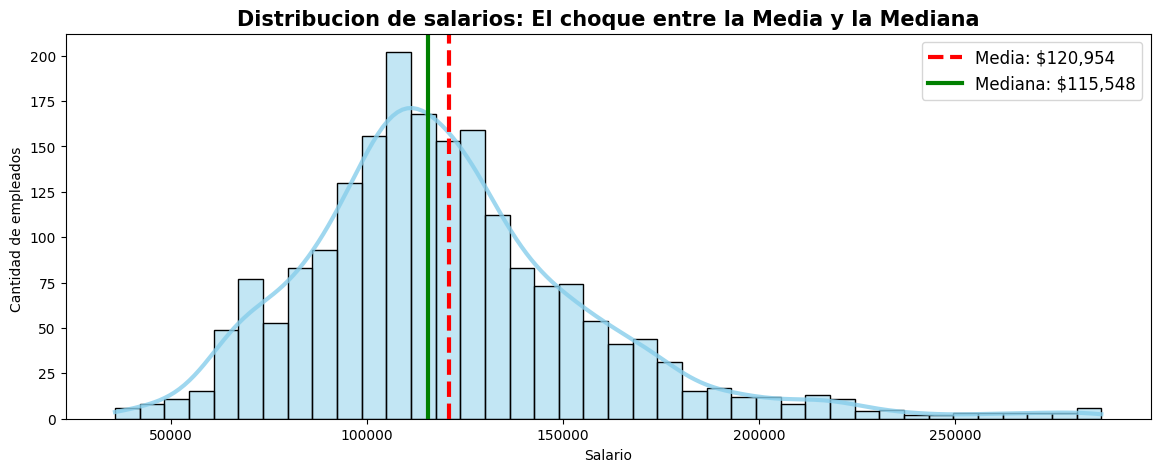

In [ ]:
media_salario = customers["Income"].mean()# Calculo la media (promedio) del salario de todos los clientes
mediana_salario = customers["Income"].median()# Calculo la mediana del salario
plt.figure(figsize=(14, 5))# Defino el tamaño de la gráfica para que se vea más grande
datos_visuales = customers[customers["Income"] < 300000] # Filtro los datos para visualizar solo salarios menores a 300000. Esto ayuda a que la gráfica no se distorsione con valores demasiado altos

# Creo el histograma de los salarios
# bins=40 divide los datos en 40 grupos
sns.histplot(datos_visuales["Income"], bins=40, color="skyblue", kde=True, #kde=una curva de una funcion
             line_kws={"linewidth": 3, "color": "navy", "alpha": 0.8}) # estilo de la curva
plt.axvline(media_salario, color="red", linestyle="dashed", linewidth= 3, label=f'Media: ${media_salario:,.0f}')# Dibujo una línea vertical para mostrar la media de los salarios
plt.axvline(mediana_salario, color="green", linestyle="solid", linewidth= 3, label=f'Mediana: ${mediana_salario:,.0f}')# Dibujo una línea vertical para mostrar la mediana

plt.title("Distribucion de salarios: El choque entre la Media y la Mediana", fontsize=15, fontweight="bold")# Título de la gráfica
plt.xlabel("Salario")# Etiqueta del eje X
plt.ylabel("Cantidad de empleados ")# Etiqueta del eje Y
plt.legend(fontsize=12)# Muestro la leyenda para identificar las líneas

##Analisis de el Histograma

Observo que la mayoría de los salarios se concentran aproximadamente entre 90.000 y 140.000, donde se encuentra la mayor cantidad de empleados.

La línea azul en forma de curva ayuda a ver más claramente cómo están distribuidos los salarios y en qué valores se concentran más.

También se muestran dos líneas verticales:

*   La línea roja punteada representa la media ($120,954).

*   La línea verde representa la mediana ($115,548).

Como la media es mayor que la mediana, la distribución está sesgada hacia la derecha, lo que indica que existen algunos salarios muy altos que aumentan el promedio. Por esta razón, la mediana representa mejor el salario típico de los empleados.




##VIOLIN PLOT

/tmp/ipykernel_217/441715613.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Occupation", y="Income", data=datos_visuales, alpha=0.6, jitter=True, palette="Set1", size=6)


Text(0, 0.5, 'Ingresos del cliente')

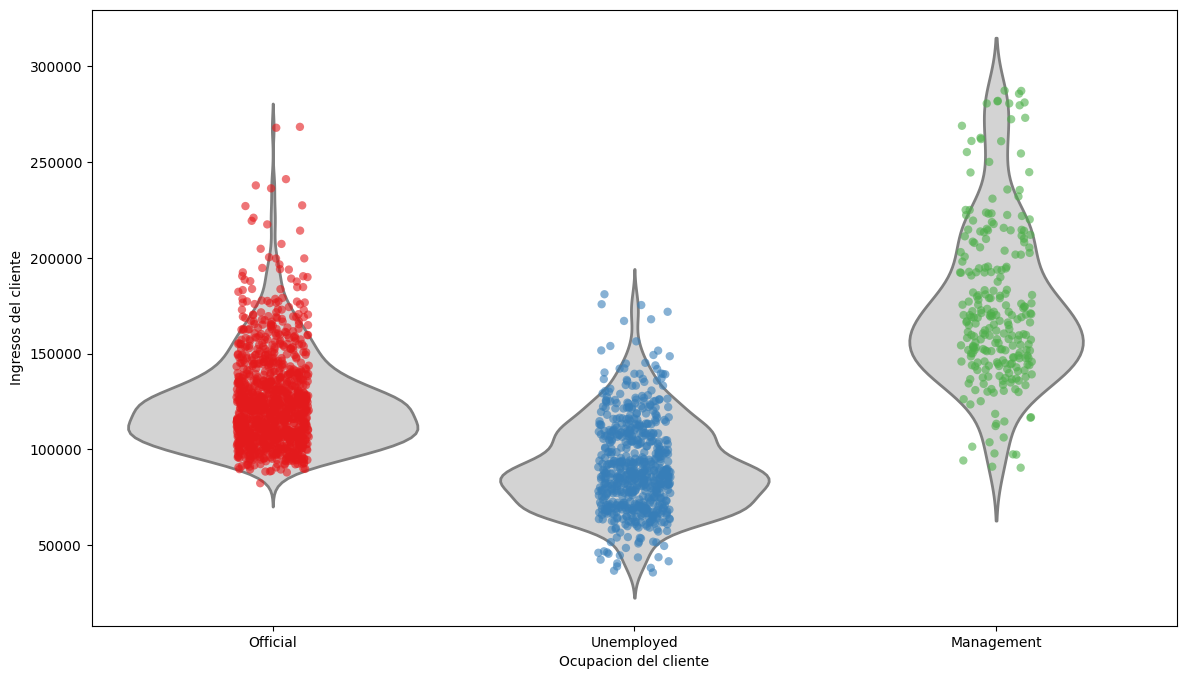

In [ ]:
# Uso un filtro para mostrar solo ingresos menores a 300.000. Esto lo hago para que los valores muy altos no deformen el gráfico
datos_visuales = customers[customers["Income"] < 300000]

plt.figure(figsize=(14, 8))# Defino el tamaño de la figura

# Creo un gráfico tipo violín para ver cómo se distribuyen los ingresos (según la ocupación del cliente)
sns.violinplot(x="Occupation", y="Income", data=datos_visuales,
               color="lightgray", inner=None, linewidth=2)# quito las líneas internas del violín
# Agrego los puntos de cada dato individual encima del gráfico
sns.stripplot(x="Occupation", y="Income", data=datos_visuales, alpha=0.6, jitter=True, palette="Set1", size=6)
plt.xlabel("Ocupacion del cliente")# Etiqueta del eje X
plt.ylabel("Ingresos del cliente")# Etiqueta del eje y

##Analisis Violin plot
En esta gráfica se comparan los ingresos de los clientes según su ocupación usando un gráfico de violín. Este tipo de gráfico permite ver cómo se distribuyen los ingresos en cada grupo.

Se puede observar que las personas que trabajan en Management tienen en general los ingresos más altos, ya que la mayoría de sus datos se concentran en valores superiores comparados con las otras ocupaciones.

Por otro lado, las personas Unemployed presentan los ingresos más bajos, con la mayor concentración de datos entre aproximadamente 60,000 y 100,000.

En el caso de Official, los ingresos se encuentran en un rango intermedio, con muchos valores alrededor de 100,000 a 130,000.

Los puntos muestran cada observación individual, mientras que la forma del violín permite ver dónde hay mayor concentración de datos en cada ocupación.

##Boxplot

/tmp/ipykernel_217/2406186543.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Education", y="Income", data=datos_visuales, palette="Set2", width=0.6)


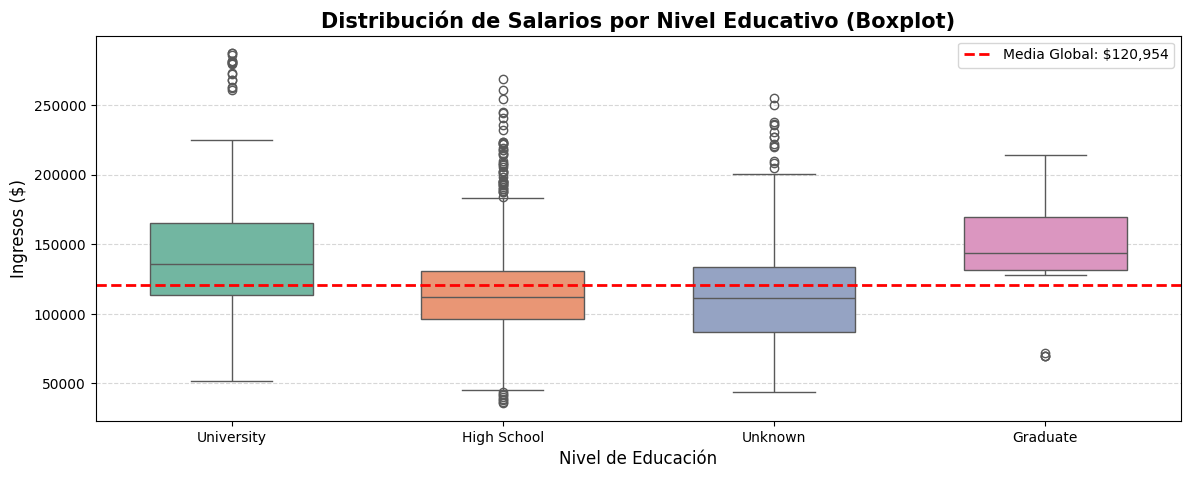

In [ ]:
#Configuramos el tamaño de la imagen
plt.figure(figsize=(14, 5))

# Creo el Boxplot dependiendo del nivel de educación
# Usamos 'datos_visuales' (el filtro < 300k que creaste) para que no se vea comprimido
# Uso los datos filtrados (ingresos menores a 300k)
sns.boxplot(x="Education", y="Income", data=datos_visuales, palette="Set2", width=0.6)

# Añadimos la línea de la media global
plt.axhline(media_salario, color="red", linestyle="--", linewidth=2, label=f'Media Global: ${media_salario:,.0f}')


plt.title("Distribución de Salarios por Nivel Educativo (Boxplot)", fontsize=15, fontweight="bold")#Titulo de la grafica
plt.xlabel("Nivel de Educación", fontsize=12)# Nombre del eje X
plt.ylabel("Ingresos ($)", fontsize=12)# Nombre del eje Y
plt.legend(fontsize=10)# Muestro la leyenda

# Mostramos la cuadrícula solo en el eje Y para facilitar la lectura de montos
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()# Muestro la gráfica

##Analisis Boxplot

Se puede observar que las personas con nivel Graduate tienen en general ingresos más altos, ya que la mayor parte de sus datos se encuentra por encima de los otros niveles educativos.

Las personas con High School presentan ingresos más bajos en comparación con los demás grupos, mientras que University se encuentra en un nivel intermedio.

La línea roja punteada representa la media global de los ingresos, lo que permite comparar si los ingresos de cada grupo están por encima o por debajo del promedio general.


In [ ]:
#1. Calculo del estadistico r de Pearson
correlacion = customers[['Age','Income']].corr(method='pearson')
print('Matriz de correlacion:')
display(correlacion)

Matriz de correlacion:


,Age,Income
Age,1.00000,0.34061
Income,0.34061,1.00000


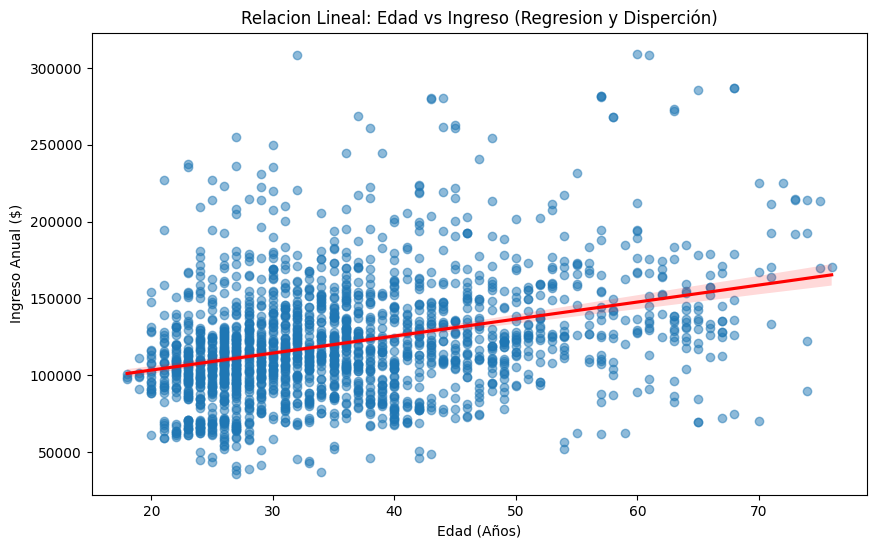

In [ ]:
#2. Visualizaión de la relaacion (Scatterplot con linea de tendendia)
plt.figure(figsize=(10, 6))
sns.regplot(data=customers, x='Age', y='Income', scatter_kws={'alpha': 0.5}, line_kws={'color':'red'})
plt.title('Relacion Lineal: Edad vs Ingreso (Regresion y Disperción)')
plt.xlabel('Edad (Años)')
plt.ylabel('Ingreso Anual ($)')
plt.show()

Solucion y Analisis Esctructurado (Para discutir

1. **Interpretación del Coeficiente (r):** El cálculo nos devuelve un valor positivo. Como la línea roja (tendencia) va hacia arriba, confirmamos una correlación **positiva**

2. **Fuerza de la relación:** Al observar el valor numérico (usualmente alrededor de 0.3 - 0.5 para este dataset), sabemos que la correlación es **moderada/débil.**

3. **Conclusión Analítica:** La hipótesis se aprueba parcialmente. Sí, a mayor edad hay una tendencia de ganar más, pero la dispersión de los puntos indica que **la edad no explica el 100% de la varianza del ingreso**. Hay jóvenes ganando mucho y adultos mayores ganando poco. Debemos buscar otras variables.

Text(0, 0.5, 'Ingresos (USD)')

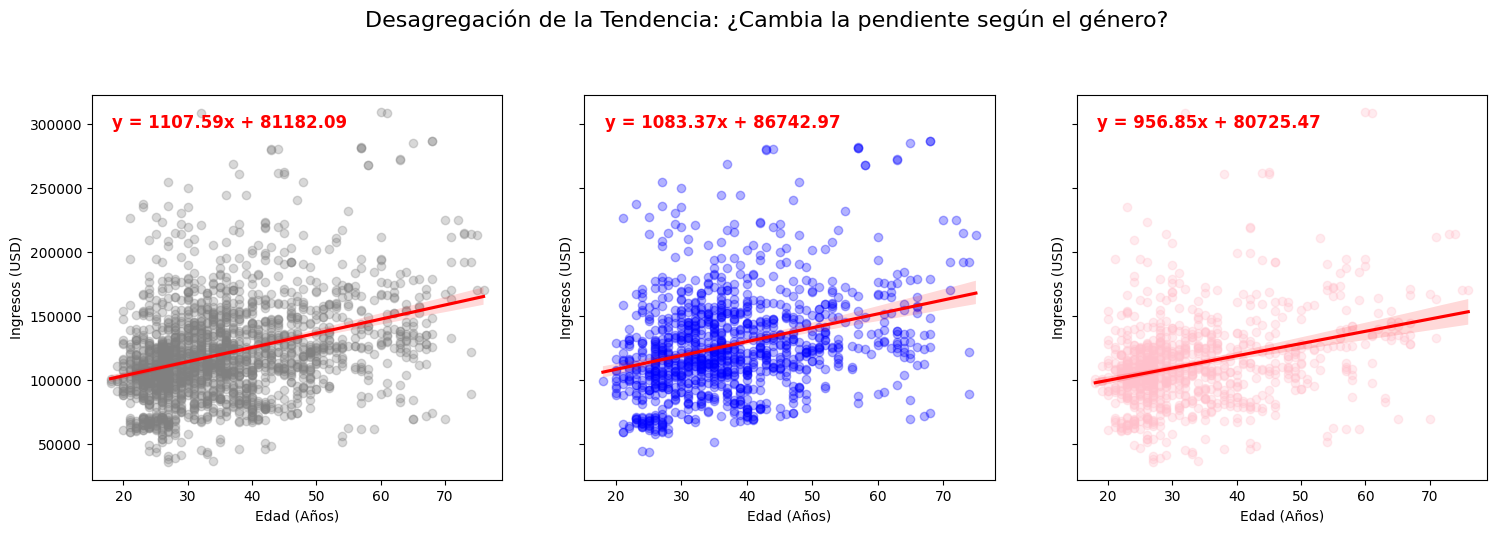

In [ ]:
#Creamos una figura con 1 fila y 3 columnas \n"
fig, axes = plt.subplots(1, 3, figsize = (18, 5), sharey=True)
plt.suptitle('Desagregación de la Tendencia: ¿Cambia la pendiente según el género?', fontsize=16, y=1.05)
#1. Plot de todos juntos (Gris y Rojo)\n
sns.regplot(data=customers, x ='Age', y ='Income', ax=axes[0], scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
m1, b1 = np.polyfit(customers['Age'], customers['Income'], 1)
axes[0].text(0.05, 0.95, f'y = {m1:.2f}x + {b1:.2f}', transform=axes[0].transAxes,
             color='red', fontsize=12, fontweight='bold', va = 'top')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Ingresos (USD)')

#2. HOMBRES(Blue)
sns.regplot(data=df_hombres, x ='Age', y ='Income', ax=axes[1], scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
m2, b2 = np.polyfit(df_hombres['Age'], df_hombres['Income'], 1)
axes[1].text(1.25, 0.95, f'y = {m2:.2f}x + {b2:.2f}', transform=axes[0].transAxes,
             color='red', fontsize=12, fontweight='bold', va = 'top')
axes[1].set_xlabel('Edad (Años)')
axes[1].set_ylabel('Ingresos (USD)')

#2 Mujeres(Pink)
sns.regplot(data=df_mujeres, x ='Age', y ='Income', ax=axes[2], scatter_kws={'alpha':0.3, 'color':'pink'}, line_kws={'color':'red'})
m3, b3 = np.polyfit(df_mujeres['Age'], df_mujeres['Income'], 1)
axes[2].text(2.45, 0.95, f'y = {m3:.2f}x + {b3:.2f}', transform=axes[0].transAxes,
             color='red', fontsize=12, fontweight='bold', va = 'top')
axes[2].set_xlabel('Edad (Años)')
axes[2].set_ylabel('Ingresos (USD)')


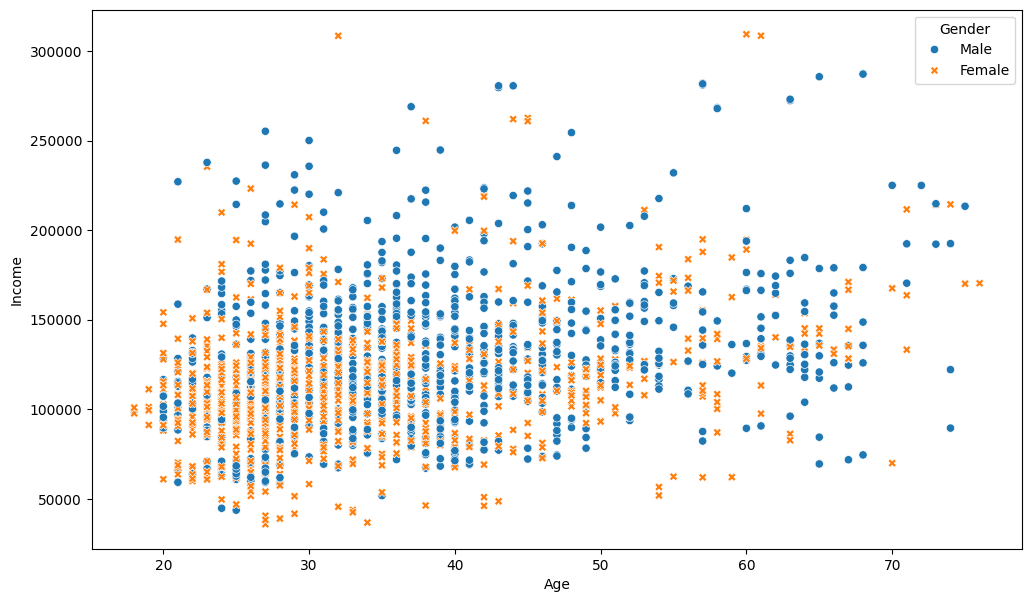

In [ ]:
plt.figure(figsize=(12, 7))

#Grafico multivariado: X=Age, Y=Income, Color= Marital Status, Forma= Gender
sns.scatterplot(data=customers, x='Age', y='Income', hue='Gender', style='Gender')
plt.show()



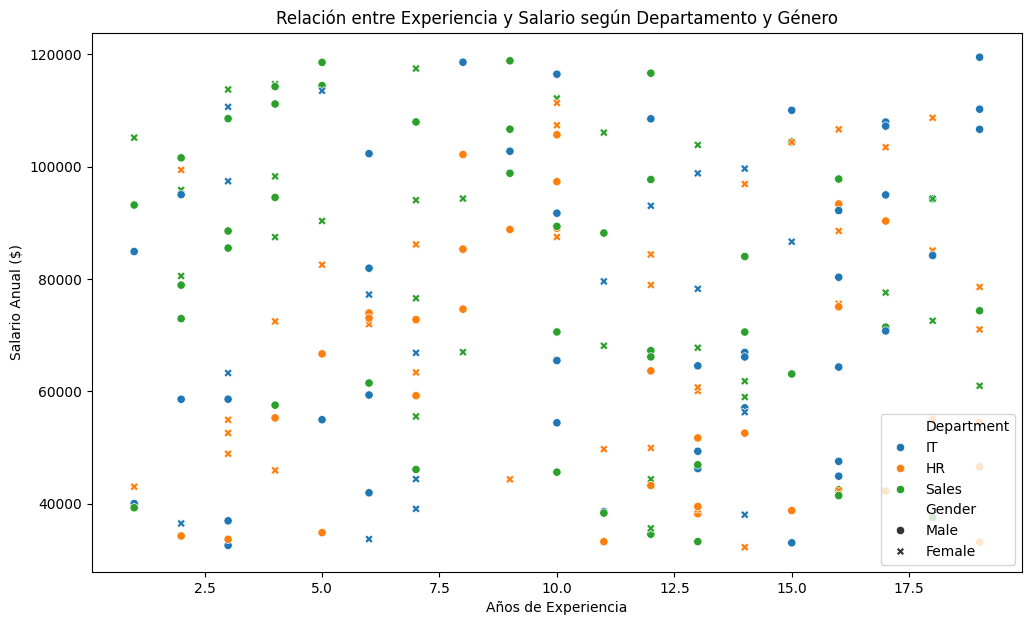

In [ ]:

customers = pd.DataFrame({
    "Experience": np.random.randint(1, 20, 200),
    "Salary": np.random.randint(30000, 120000, 200),
    "Department": np.random.choice(["Sales", "IT", "HR"], 200),
    "Gender": np.random.choice(["Male", "Female"], 200)
})

plt.figure(figsize=(12, 7))


sns.scatterplot(data=customers,x='Experience',y='Salary',hue='Department',style='Gender')


plt.title("Relación entre Experiencia y Salario según Departamento y Género")
plt.xlabel("Años de Experiencia")
plt.ylabel("Salario Anual ($)")

plt.show()

In [ ]:
import plotly.express as px
#Creamos el mismo grafico disperso, pero añadiendo toda la data subyacente al pasar el cursor.
fig= px.scatter(customers)

##**Tareas:** crear graficas con ese tipo de codigo

##**Hasta la proximo clase**
Carga en github todo:
para tener en cuent:
*todo lo que hemos hecho en clase este ahi.
*comentarios
*No tener similitudes con otros trabajos
Copiamos el link del repositorio y lo ponemos en el chat del grupo